In [ ]:

from google.colab import files

# This will open a file browser to upload your CSV
uploaded = files.upload()

# Install unrar if not already present
!sudo apt-get install unrar

# Extract the file
# 'x' stands for extract with full paths (keeping your folder structure)
!unrar x "/content/CMATERdb 3.1.2.rar" "/content/abc/"

TypeError: 'NoneType' object is not subscriptable

In [ ]:

# Install required libraries
!pip install tensorflow pandas scikit-learn seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Import Neural Network components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten

# These are the essential imports for a Neural Network to work with image data
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:

import tensorflow as tf

# Define where your images are (after you have run the !unrar command)
data_dir = "/content/dataset/BasicFinalDatabase"

# This automatically finds your folders ('Train' and 'Test')
# and treats each subfolder as a different class (label)
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/Train",
    seed=123,
    image_size=(32, 32), # Resizes images to be consistent
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/Test",
    seed=123,
    image_size=(32, 32),
    batch_size=32
)

print("Data loaded successfully! You are ready to build the model.")

Found 12000 files belonging to 50 classes.
Found 3000 files belonging to 50 classes.
Data loaded successfully! You are ready to build the model.


In [ ]:

import os
import shutil

# 1. Install patool to handle .rar files in Colab
!pip install patool
import patoolib

# 2. Define filenames and folders
rar_filename = "CMATERdb 3.1.2.rar"
extract_to = "dataset"

# Clean up previous attempts
if os.path.exists(extract_to):
    shutil.rmtree(extract_to)
os.makedirs(extract_to)

# 3. Extract the RAR file
print("Extracting...")
patoolib.extract_archive(rar_filename, outdir=extract_to)

# 4. Verify Structure
# Your structure is: dataset/BasicFinalDatabase/Train/...
# Let's verify the contents
dataset_path = os.path.join(extract_to, "BasicFinalDatabase")
if os.path.exists(dataset_path):
    print("Extraction successful!")
    print("Folders found:", os.listdir(dataset_path))
else:
    print("Error: Could not find BasicFinalDatabase folder.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.2 MB/s eta 0:00:00


INFO patool: Extracting CMATERdb 3.1.2.rar ...
INFO patool: running /usr/bin/unrar x -kb -or -- "/content/CMATERdb 3.1.2.rar"


Extracting...


INFO patool: ... CMATERdb 3.1.2.rar extracted to `dataset'.


Extraction successful!
Folders found: ['Test', 'Train']


In [ ]:

import tensorflow as tf

# Define where your images are (after you have run the !unrar command)
data_dir = "/content/dataset/BasicFinalDatabase"

# This automatically finds your folders ('Train' and 'Test')
# and treats each subfolder as a different class (label)
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/Train",
    seed=123,
    image_size=(32, 32), # Resizes images to be consistent
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/Test",
    seed=123,
    image_size=(32, 32),
    batch_size=32
)

print("Data loaded successfully! You are ready to build the model.")

Found 12000 files belonging to 50 classes.
Found 3000 files belonging to 50 classes.
Data loaded successfully! You are ready to build the model.


In [ ]:

import os
import cv2
import numpy as np
import tensorflow as tf

def load_data(data_dir):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            # Use OpenCV to read the image, which is much more tolerant of header errors
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (32, 32))
                images.append(img)
                labels.append(i)

    return np.array(images), np.array(labels)

# Load data from the paths
train_dir = "/content/dataset/BasicFinalDatabase/Train"
test_dir = "/content/dataset/BasicFinalDatabase/Test"

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

# Normalize data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for the Neural Network
X_train = X_train.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 1)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(50, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train using the arrays
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2077 - loss: 3.0694 - val_accuracy: 0.3763 - val_loss: 2.3807
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4629 - loss: 1.9855 - val_accuracy: 0.4803 - val_loss: 1.9153
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5388 - loss: 1.6846 - val_accuracy: 0.5260 - val_loss: 1.7065
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5903 - loss: 1.4851 - val_accuracy: 0.5580 - val_loss: 1.6453
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6218 - loss: 1.3631 - val_accuracy: 0.5857 - val_loss: 1.5080
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6532 - loss: 1.2351 - val_accuracy: 0.5957 - val_loss: 1.4789
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6795 - loss: 1.1272 - val_accuracy: 0.6117 - val_loss: 1.4218
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7046 - loss: 1.0372 - val_accuracy: 

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6543 - loss: 1.2907
Test Accuracy: 65.43%


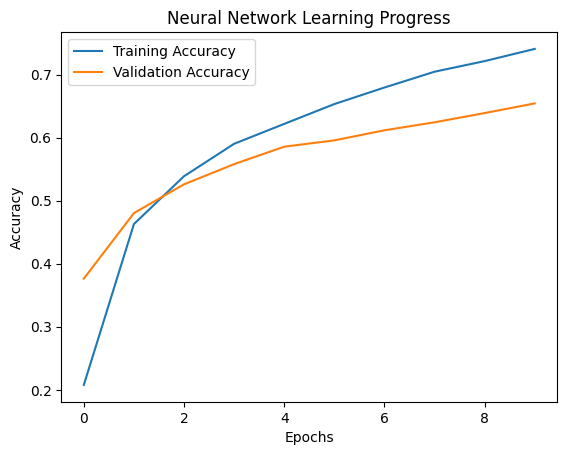

In [ ]:

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Plot the training history to show learning progress
import matplotlib.pyplot as plt

plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Learning Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()